# plotnine and ridgeline-like graphics

## Introduction

There is a __ridgeline__ extension in __R__ for drawing the distribution of a numeric variable for several groups. In this example, we check the montrhly distribution of daily temperature.

There is no __geom_ridgeline__ in plotnine.  However we can come close.  This post is about how close we can get.

## Implementation

### Imports

Packages:

- datetime handles datetime calculations
- warnings acn be sued to supress warning from plotnine
- numpy does numerical calculations
- pandas handles dataframe



In [28]:
import datetime
import warnings

import numpy as np
import pandas as pd
import plotnine as p9
import scipy

__watermark__ produces reproducability information

In [29]:
%load_ext watermark

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark


-------------------------

## Data setup

We create dummy data, assigning a temperature to every day of the year, given the  average and standard deviation for each month

In [30]:
averages = [10, 11, 14, 18, 23, 26, 29, 32, 25, 18, 14, 6]
sd = [3, 3, 4, 6, 7, 8, 5, 5, 4, 7, 4, 3]

date = [datetime.date(2022, 1, 1) + datetime.timedelta(days=i) for i in range(365)]

Note some overloading of names: there is a column "month" that holds the long name of the month.  There is also a datetime attribute "month" that gives you a month number (1-12).  We use this to build our random temperature value, assuming a Guassian distribution of temperatures within each month

In [31]:
df = pd.DataFrame(
    {
        "date": date,
        "month": [f"{d:%B}" for d in date],
        "month_no": [d.month for d in date],
        "temp": [
            round(np.random.normal(averages[d.month - 1], sd[d.month - 1]))
            for d in date
        ],
    }
)

Check the first few rows: looks OK

In [32]:
df.head()

,date,month,month_no,temp
0,2022-01-01,January,1,10
1,2022-01-02,January,1,17
2,2022-01-03,January,1,13
3,2022-01-04,January,1,15
4,2022-01-05,January,1,10


Plotnine will by default plot discrete variables that are strings in alphabetical order:  we want the months sorted in the usual order.

I use a hack: I iterate over the months of 2000, in chronological order, and store the long names in a list.  I then tell __pandas__ that I want the column "month" to be discrete items, with a specified order.  Pandas will tell Plotnine this order.  For purposes explained below, I also want date name sorted in __reverse__ chronological order

In [33]:
# get month names in chronological order
month_names = [f"{datetime.date(2000,m,1):%B}" for m in range(1, 13)]
rev_name = list(reversed(month_names))

# set month as categorical variable
df["month"] = (
    df["month"].astype("category").cat.reorder_categories(month_names, ordered=True)
)

Check the "months" is now a category (it is)

In [34]:
df.dtypes

date          object
month       category
month_no       int64
temp           int64
dtype: object

For subsequent graphics, I compute the average temperature for each month, and assign that average  to each day of the month

In [35]:
m_av = df.groupby("month", observed=True).mean("temp")

In [36]:
m_av[0:4]

,month_no,temp
month,,
January,1.0,11.000000
February,2.0,11.285714
March,3.0,14.548387
April,4.0,19.200000


In [37]:
# set the monthly average at each date value

df["t_av"] = [m_av.loc[m, "temp"] for m in df["month"]]

Review our dataframe

In [38]:
df.head(3)

,date,month,month_no,temp,t_av
0,2022-01-01,January,1,10,11.0
1,2022-01-02,January,1,17,11.0
2,2022-01-03,January,1,13,11.0


For subsequent graphs we want the month names in reverse chronological order

In [39]:
rev_name[0:3]

['December', 'November', 'October']

-------------------------

## Violin & sina plots

There are a few __geom__ options in Plotnine that know how to draw multiple objects on the one plot.  This section is based on https://plotnine.org/gallery/temperature-over-the-year.html

We combine __violin__ and __sina__.  __geom_violin__ by default draws multiple "ridges" (really density estimates based on the daily point plots) that are vertically aligned, so we have to flip the X and Y axis to get the effect we want, by __coord_flip()__. 

__geom_sina__ draws a scatterplot, where the height of the jittered points depend upon the estimated density at that point

The steps are:

- create an empty plot, specifying our data source
- create a violin plot
  - we map month name to the x axis, temperature (for the temperature liklihood curve) to the y axis, and ask for a fill color related to average temperature
  - we ask for just the right side of the violin
  - set width (eventually height after we flip the axis)
  - set transparency 
- createa sina plot
  - we map month name to x axis, temperature to the y axis, and ask for a fill color related to temperature
  - we ask for only the right hand side of the scatter plot
  - set a maximum width of how far points are scattered from the baseline
  - set transparency to be opaque
  - set point size
  - ask for a white line to outline each point plotted
- set the order in which the months are to appear.  Just my taste, but I like January to be highest (but because January comes first, plotnine assumes it is the smallest, and by default, puts it at the bottom of the plot)
- set a thee of black&white (a cleaner looking graph)
- assign labels to various components of the plot
- flip the axis to give us horizontal density curves


C:\Users\donrc\anaconda3\envs\fun_minim\Lib\site-packages\plotnine\positions\position.py:232: PlotnineWarning: position_dodge requires non-overlapping x intervals


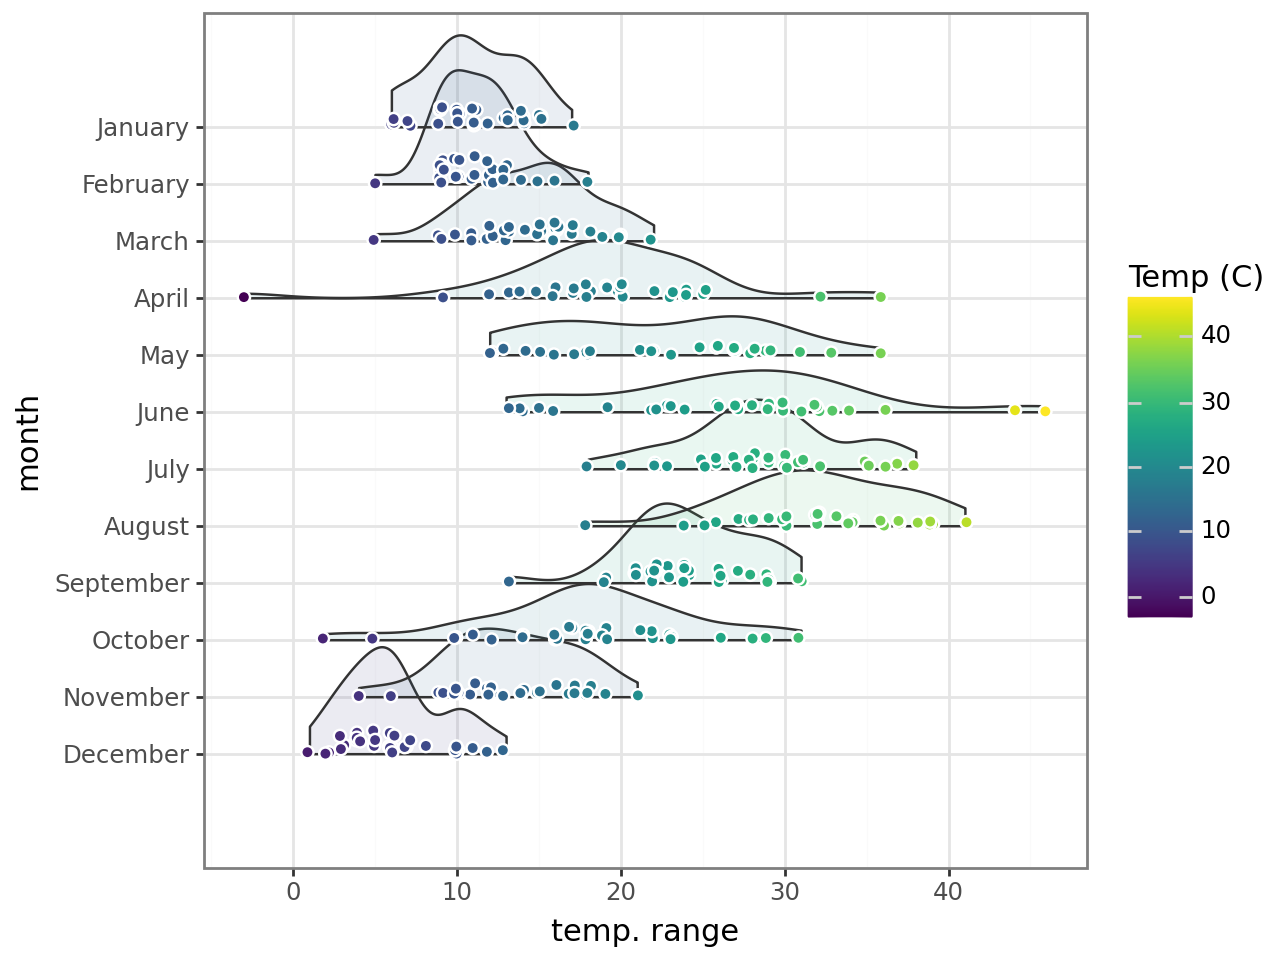

In [40]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_violin(
        mapping=p9.aes(x="month", y="temp", fill="t_av"),
        style="right",
        width=4,
        alpha=0.1,
    )
    + p9.geom_sina(
        mapping=p9.aes(x="month", y="temp", fill="temp"),
        style="right",
        maxwidth=1,
        alpha=1,
        size=2,
        color="white",
    )
    + p9.scale_x_discrete(limits=rev_name)
    + p9.theme_bw()
    + p9.labs(y="temp. range", x="month", fill="Temp (C)")
    + p9.coord_flip()
)
plot

The next iteration of this graphic replaces the __geom_sina__ scatterplot, with just plotting daily temperature on the baseline.

The steps are:

- create an empty plot, specifying our data source
- create a violin plot
  - we map month name to the x axis, temperature (for the temperature liklihood curve) to the y axis, and ask for a fill color related to average temperature
  - we ask for just the right side of the violin
  - set width (eventually height after we flip the axis) so as to cause overlap in final set of curves (as an example)
  - set transparency to almost opaque
- createa point plot
  - we map month name to x axis, temperature to the y axis
  - set transparency to be not very opaque
  - set point size
  - ask for gray points
- Note that we __don't__ set the order in which the months are to appear (call is commented out).  December is at the top:  this neans that when plotnine draws the almost opaque curves in its usual order, (e,g,) August will overlay September, giving a sense of depth
- set a thee of black&white (a cleaner looking graph)
- assign labels to various components of the plot.  We now ask for a subtitle
- flip the axis to give us horizontal density curves

C:\Users\donrc\anaconda3\envs\fun_minim\Lib\site-packages\plotnine\positions\position.py:232: PlotnineWarning: position_dodge requires non-overlapping x intervals


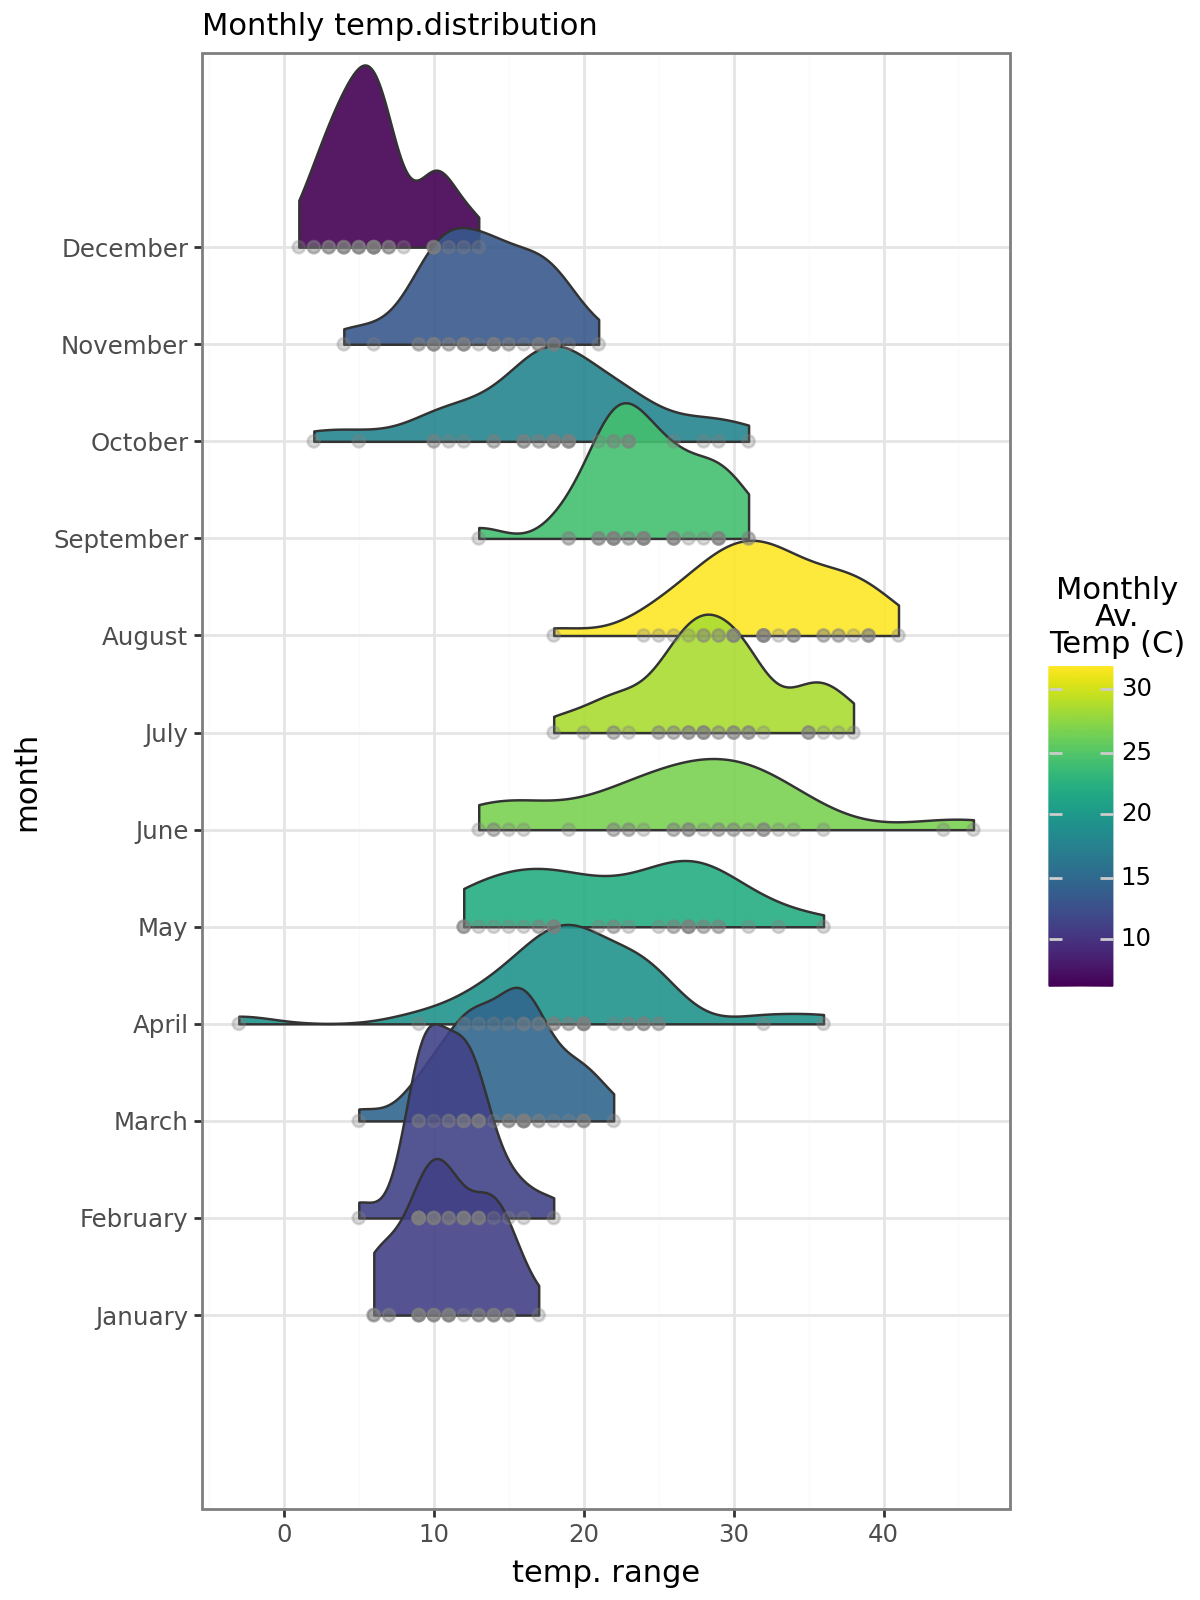

In [41]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_violin(
        mapping=p9.aes(x="month", y="temp", fill="t_av"),
        style="right",
        width=4,
        alpha=0.9,
    )
    + p9.geom_point(
        mapping=p9.aes(
            x="month",
            y="temp",
        ),
        alpha=0.3,
        size=2,
        color="gray",
    )
    # + p9.scale_x_discrete(limits=rev_name)
    + p9.theme_bw()
    + p9.theme(figure_size=(6, 8))
    + p9.labs(
        y="temp. range",
        x="month",
        fill="Monthly\nAv.\nTemp (C)",
        subtitle="Monthly temp.distribution",
    )
    + p9.coord_flip()
)
plot

-----------------------

## Shifted lines

There is an alternative approach to ridgeline plots.  We draw multiple line-oriented graphics, shifting each one up depending upon the month number.  Detailed explaation is below, but first we want to use month abbreviation in our graphics

### set up month abbreviations

In [42]:
rev_name_short = [s[0:3] for s in rev_name]
name_short = list(reversed(rev_name_short))
name_short[0:4]

['Jan', 'Feb', 'Mar', 'Apr']

Replace long month names with month abbreviation in our source dataframe

In [43]:
df["month"] = df["month"].str[0:3]
df["month"] = df["month"].astype("category")
df["month"] = df["month"].cat.reorder_categories(name_short)

### using the plotnine processing pipeline

We can take advantage of the plotnine processing pipleline.  We:
- ask for  __stat_density__ to run, and generate pseudo-variables including scaled density (called "scaled")
- ask for __geom_ribbon__ to generate the graphic
- ask for processing to be done on groups of data (here, grouped by month).  __stat_density__ will create a pseudo-variable "group", and assign an incrementing value for each monthly group of data

Now in the __stat_density__ call, we must map temperature to "x" (all __stat_density__ needs is a set of x coordinate positions on the baseline, from which it produces a density estimate).  __geom_ribbon__ needs a mapping to "ymax"and "ymin" (the top and bottom of the ribbon).  We set "ymin" to  the "group" pseudo-variable (as computed by __stat_density__, i.e. the baseline), and "ymax" to the baseline ("group") plus the scaled_to_one density ("scaled").  We use the __stage()__ function to indicate that these mappings __only__ apply __after__ the statistical processing

The steps are:

- create an empty plot, specifying our source of data
- ask for __stat_density__ to run
    - specify the mappings that both __stat_density__ and __geom_ribbon__ need:
      - set x axis to be mapped to temperature
      - group data by month
      - specify that ymax (needed after statistical process is done, and in graphic production) is mapped to the scaled_to_one density estimate plus the group number
      - specify that ymin (needed after statistical process is done, and in graphic production) is mapped to  the group number
      - specify that each ribbon fill is mapped to the average temperature (from the dataframe column "t_av")
    - set the __geom__ to produce the graphic to be __geom_ribbon__
- set the black&white theme for a cleaner plot
- set the tickmarks and labels on the y axis (show all months, using month abbreviations) (the scale_y_continuous call)
- label components of the plot

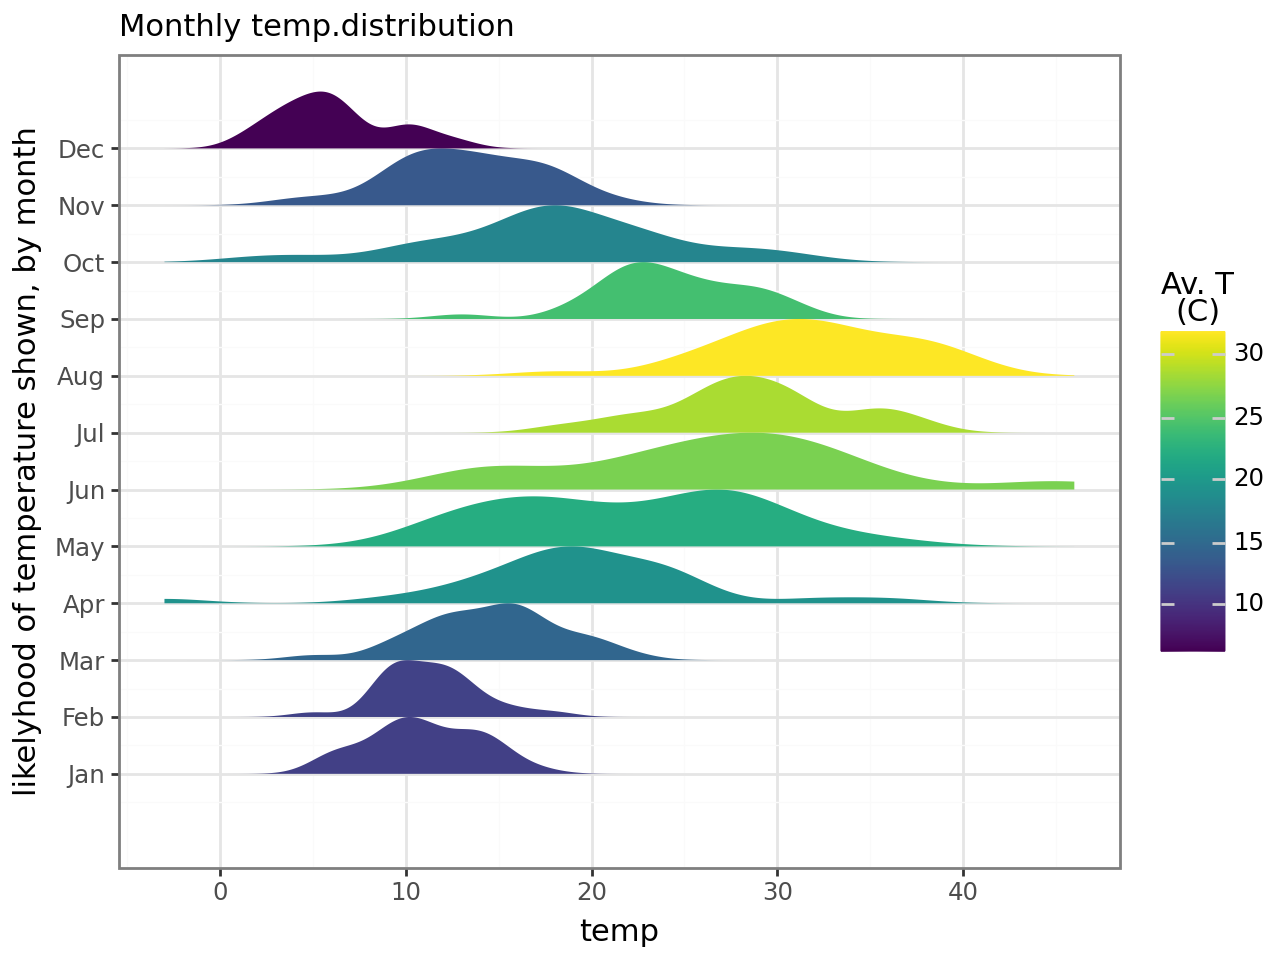

In [44]:
plot = (
    p9.ggplot(data=df)
    + p9.stat_density(
        mapping=p9.aes(
            x="temp",
            group="month",
            ymax=p9.stage(
                start=0,
                after_stat="scaled+group",
            ),
            ymin=p9.stage(
                start=0,
                after_stat="group",
            ),
            fill="t_av",
        ),
        geom="ribbon",
    )
    + p9.theme_bw()
    + p9.scale_y_continuous(
        breaks=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], labels=name_short
    )
    + p9.labs(
        fill="Av. T\n(C)",
        subtitle="Monthly temp.distribution",
        y="likelyhood of temperature shown, by month",
    )
)
plot

### using __geom_line__

We can produce a variation of this theme, by using __geom_ribbon__ to produce a gray fill under a thick line plot (one line per month, shifted up to the months position)

The steps are:

- create an empty plot, specifying our source of data
- ask for __stat_density__ to run
    - specify the mappings that both __stat_density__ and __geom_line__ need:
      - set x axis to be mapped to temperature
      - group data by month
      - specify that y (needed after statistical process is done, and in graphic production) is mapped to the scaled_to_one density estimate plus the group number
      - specify that each line color is mapped to the average temperature (from the dataframe column "t_av")
      - set size (thickness) of line
- create a ribbon plot as described above except just having gray fill
- set the black&white theme for a cleaner plot
- set the tickmarks and labels on the y axis (show all months, using month abbreviations) (the scale_y_continuous call)
- label components of the plot

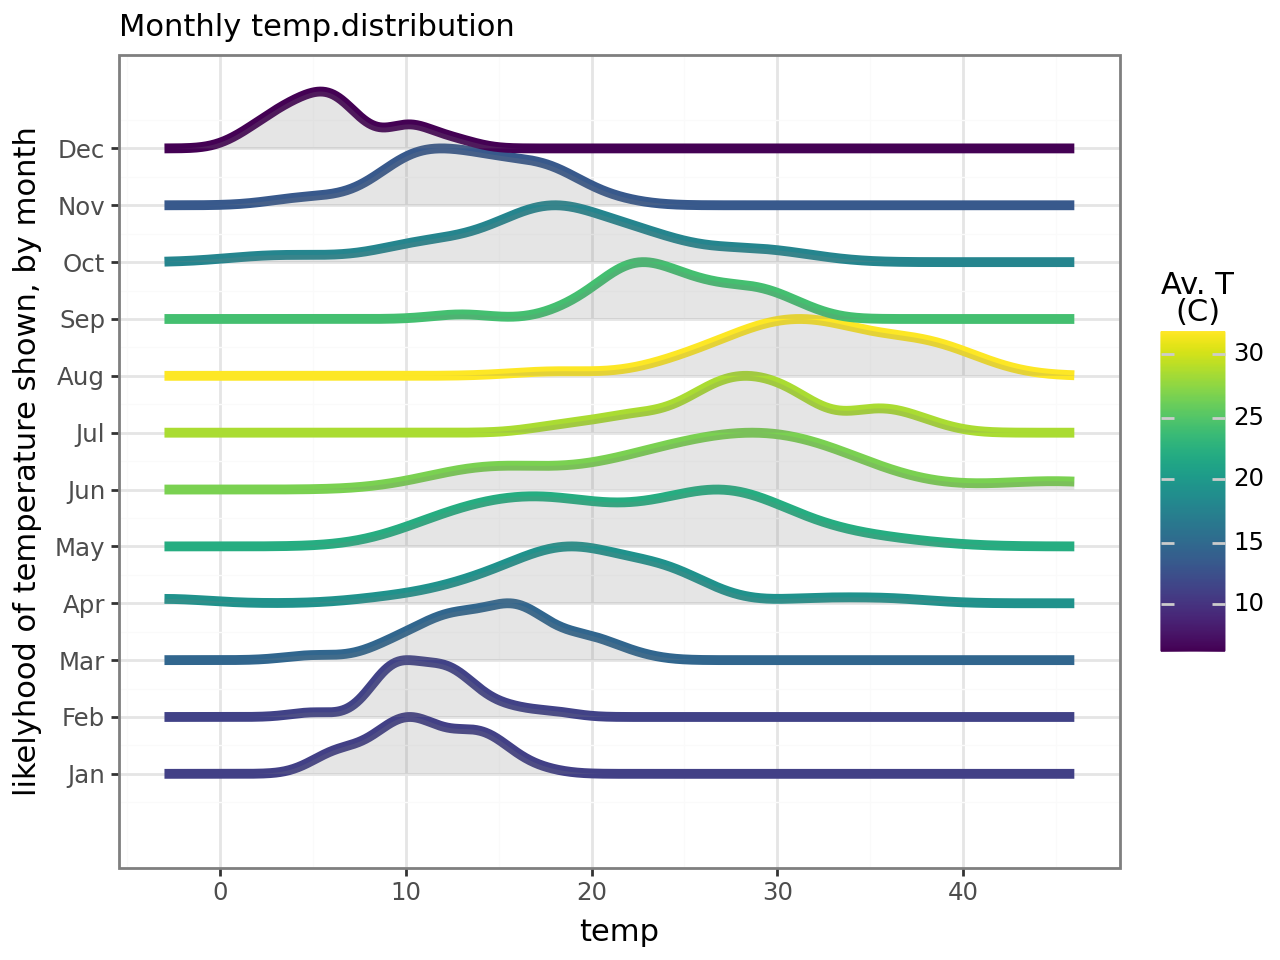

In [45]:
plot = (
    p9.ggplot(data=df)
    + p9.stat_density(
        mapping=p9.aes(
            x="temp",
            group="month",
            y=p9.stage(
                start=0,
                after_stat="scaled+group",
            ),
            color="t_av",
        ),
        geom="line",
        size=2,
    )
    + p9.stat_density(
        mapping=p9.aes(
            x="temp",
            group="month",
            ymax=p9.stage(
                start=0,
                after_stat="scaled+group",
            ),
            ymin=p9.stage(
                start=0,
                after_stat="group",
            ),
        ),
        geom="ribbon",
        fill="gray",
        alpha=0.2,
    )
    + p9.theme_bw()
    + p9.scale_y_continuous(
        breaks=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], labels=name_short
    )
    + p9.labs(
        color="Av. T\n(C)",
        subtitle="Monthly temp.distribution",
        y="likelyhood of temperature shown, by month",
    )
)
plot

-------------------------
## facet_grid

The next approach is to use __facets__, being the __plotnine__ method for producing multiple graphic from the one dataset.  We ask for a graphic (one for each month), arranged vertically.

There is some customization involved, as I want the result to look like one graphic, not a column of graphics.  As such, I strip away a lot of what in this case is "chart-junk".

In the first example, we draw histograms of daily temperature.

The steps are:

- create an empty plot, defining our data source
- ask for histograms
    - mapping:
        - x axis to temperature
        - grouping the data into monthly batches
        - the fill of each column of the histogram to a color related to the temperature (now labelled "x"after the staistical processing)
    - set color of outline to be gray
    - set fill to be mostly opaque (alpha value)
- request a multiple graphic, with each month stacked above the previous( rows="month")
- set a black&white theme for a cleaner  graph
- remove the border for each of the small individual graphics
- set the label for each small graphic to be horizontal
- set the y axis tick marks to be at 0 and 15
- draw a x=0 line (handcrafted y axis)
- labels components of the graphic





C:\Users\donrc\anaconda3\envs\fun_minim\Lib\site-packages\plotnine\stats\stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 13'. Pick better value with 'binwidth'.


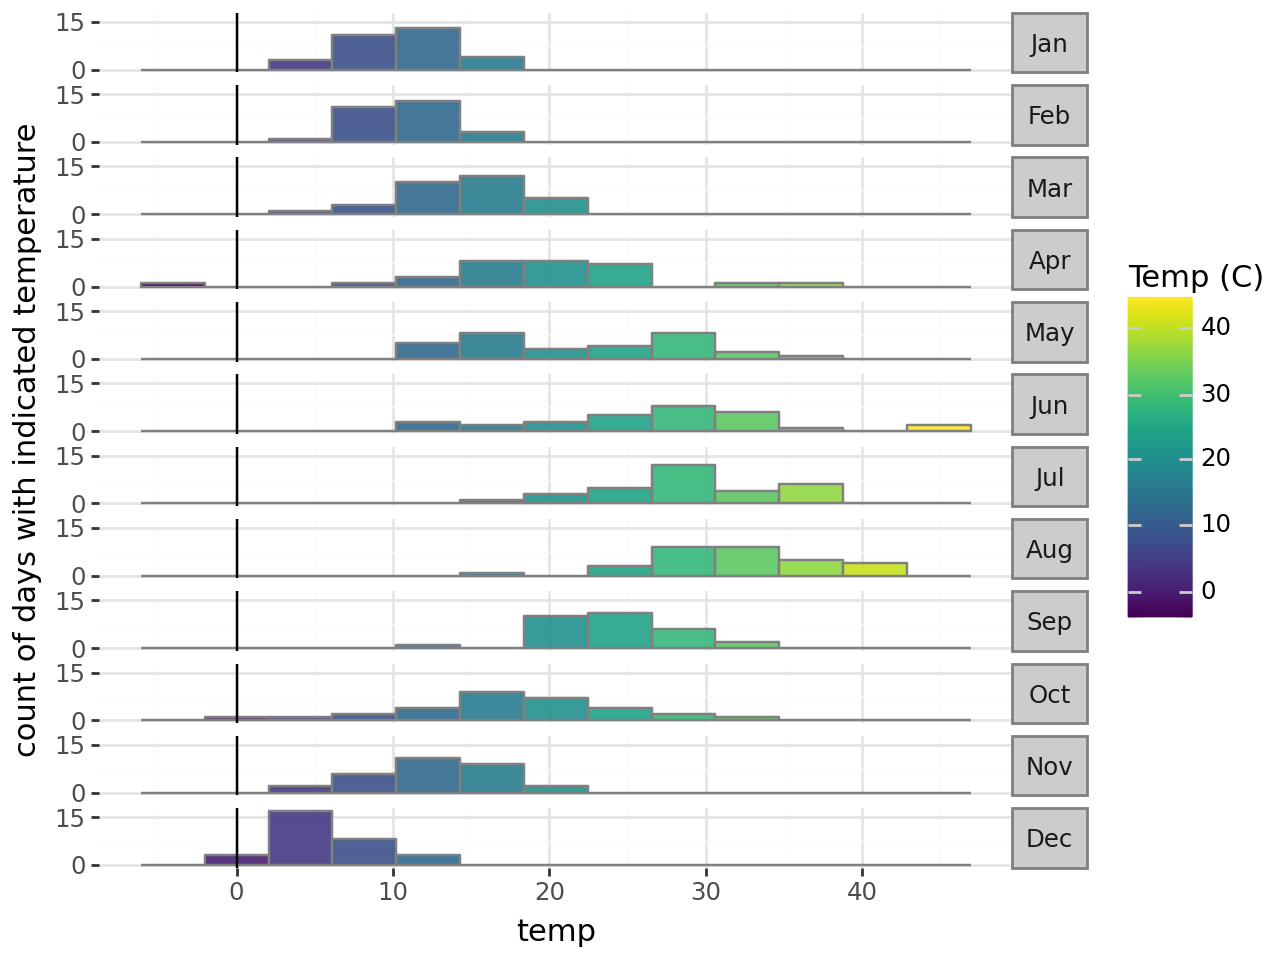

In [46]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_histogram(
        mapping=p9.aes(
            x="temp",
            group="month",
            fill=p9.after_stat("x"),
        ),
        color="gray",
        alpha=0.9,
    )
    + p9.facet_grid(rows="month")
    + p9.theme_bw()
    + p9.theme(
        panel_border=p9.element_blank(),
        strip_text_y=p9.element_text(angle=0),
    )
    + p9.scale_y_continuous(breaks=[0, 15])
    + p9.geom_vline(mapping=p9.aes(xintercept=0))
    + p9.labs(
        fill="Temp (C)",
        y="count of days with indicated temperature",
    )
)
plot

We can do almost exactly the same code for smooth density estimates.

In this case, I have removed all the y axis items (including grid lines), as they didn't contribute much in this context

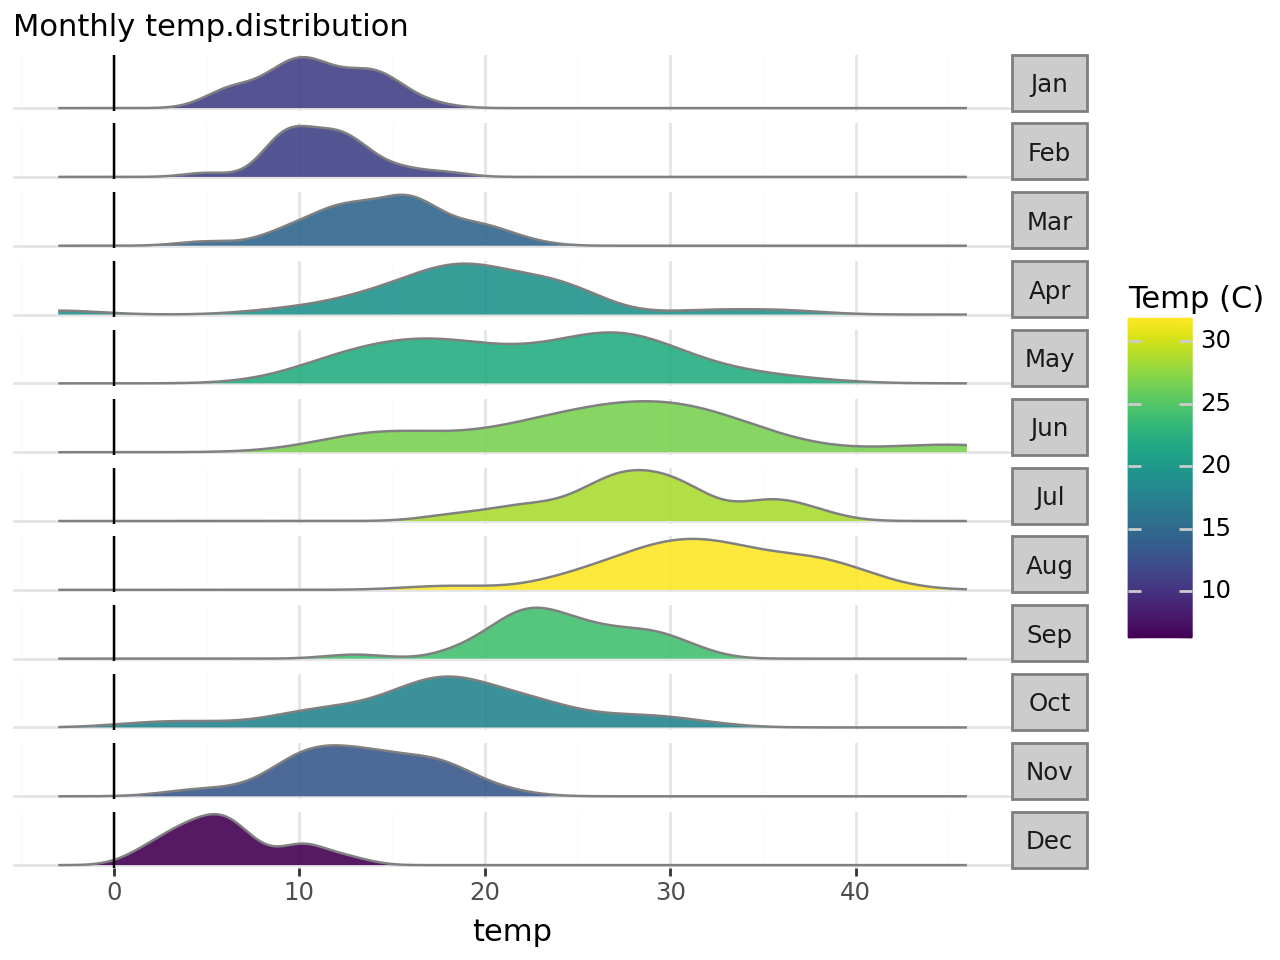

In [47]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_density(
        mapping=p9.aes(
            x="temp",
            group="month",
            y=p9.stage(
                start=0,
                after_stat="scaled",
            ),
            fill="t_av",
        ),
        color="gray",
        alpha=0.9,
    )
    + p9.facet_grid(rows="month")
    + p9.theme_bw()
    + p9.theme(
        panel_border=p9.element_blank(),
        strip_text_y=p9.element_text(angle=0),
        axis_text_y=p9.element_blank(),  # Removes the tick labels
        axis_title_y=p9.element_blank(),  # Removes the axis title
        axis_ticks_major_y=p9.element_blank(),
    )
    + p9.scale_y_continuous(breaks=[0, 15])
    + p9.geom_vline(mapping=p9.aes(xintercept=0))
    + p9.labs(fill="Temp (C)", subtitle="Monthly temp.distribution")
)
plot

---------------------

## Plotting of daily data

Another approach is to just plot the daily temperature for each month, and stack these graphs via __facet_grid__

First, we need a day-of-month column 

In [48]:
df["d_of_m"] = pd.to_datetime(df["date"]).dt.day
df.head()

,date,month,month_no,temp,t_av,d_of_m
0,2022-01-01,Jan,1,10,11.0,1
1,2022-01-02,Jan,1,17,11.0,2
2,2022-01-03,Jan,1,13,11.0,3
3,2022-01-04,Jan,1,15,11.0,4
4,2022-01-05,Jan,1,10,11.0,5


The steps are:

- create and empty plot, setting the default data source
- create a line graph (using __geom_path___ with:
    -  mapping
      - day of month is mapped to x axis
      - temperature is mapped to y axis
      - data is grouped by month
    - transparency set to almost opaque
- create a rug plot:
  - mapping:
        - y axis = temperature
        - setting color of each rug whisker based upon the temperature
        - grouping data by month
   - set transparency
   - set line thickness (size)
   - suppress legend (it will drawn for fill, don't need a duplicate for color)
- create an area plot (essentially filling in under the line we drew above (__geom__path__)
- create a horizontal line to be the baseline for the area plot
- ask for multiple graphs, stacked by month (rows="month")
- ask for a black&white theme to get a cleaner graphic
- use a theme call to:
    - turn off the border for each mini-graphic,
    - set mini-graphic labels to be horizontal
    - clear the y axis tick mark labels to be very small,
    - supress the y axis gridlines
- set y axis tick mark locations (essentially top and bottom of range)
- label components of the graphic

The color-coded rug plots on the left hand side are very subtle, but I feel they provide a good visualization of the daily temperature range, in the context fo the daily temperature strip chart


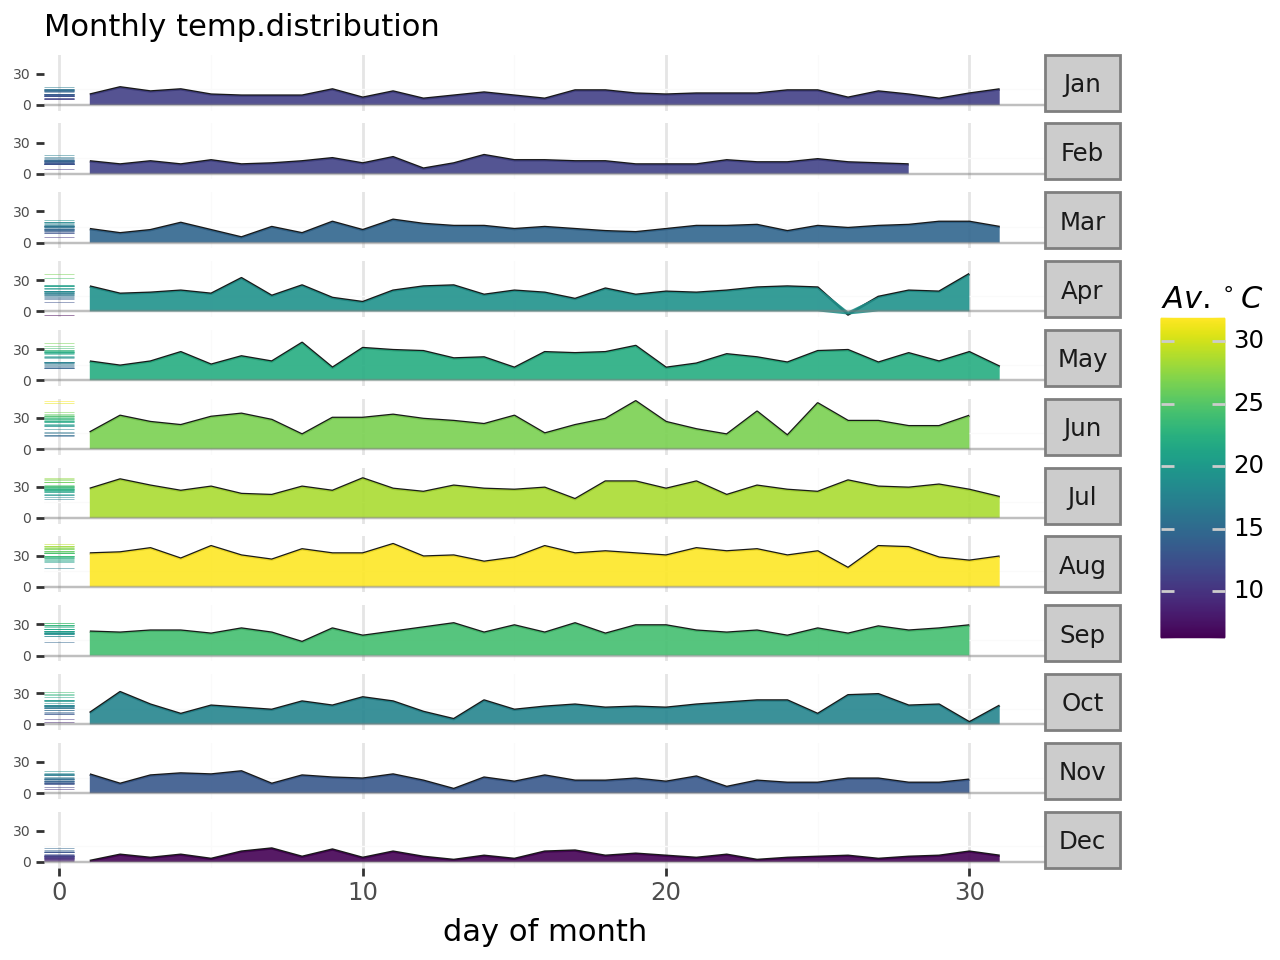

In [49]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_path(
        mapping=p9.aes(
            x="d_of_m",
            group="month",
            y="temp",
        ),
        alpha=0.9,
    )
    + p9.geom_rug(
        mapping=p9.aes(y="temp", group="month", color="temp"),
        alpha=0.5,
        size=0.2,
        show_legend=False,
    )
    + p9.geom_area(
        mapping=p9.aes(x="d_of_m", group="month", y="temp", fill="t_av"),
        alpha=0.9,
    )
    + p9.geom_hline(
        mapping=p9.aes(yintercept=0),
        color="gray",
        alpha=0.5,
    )
    + p9.facet_grid(rows="month")
    + p9.theme_bw()
    + p9.theme(
        panel_border=p9.element_blank(),
        strip_text_y=p9.element_text(angle=0),
        axis_text_y=p9.element_text(size=5),
        panel_grid_major_y=p9.element_blank(),
    )
    + p9.scale_y_continuous(breaks=[0, 30])
    + p9.labs(
        fill="$Av. ^\circ C$",
        x="day of month",
        y="",
        subtitle="Monthly temp.distribution",
    )
)
plot

In this example, we have plotted a bar chart for each month, with the fill of each column mapped to temperature.  The calls are essentially the same as above (no __geom_rug__ call, __geom_col__ replaces __geom_path__)

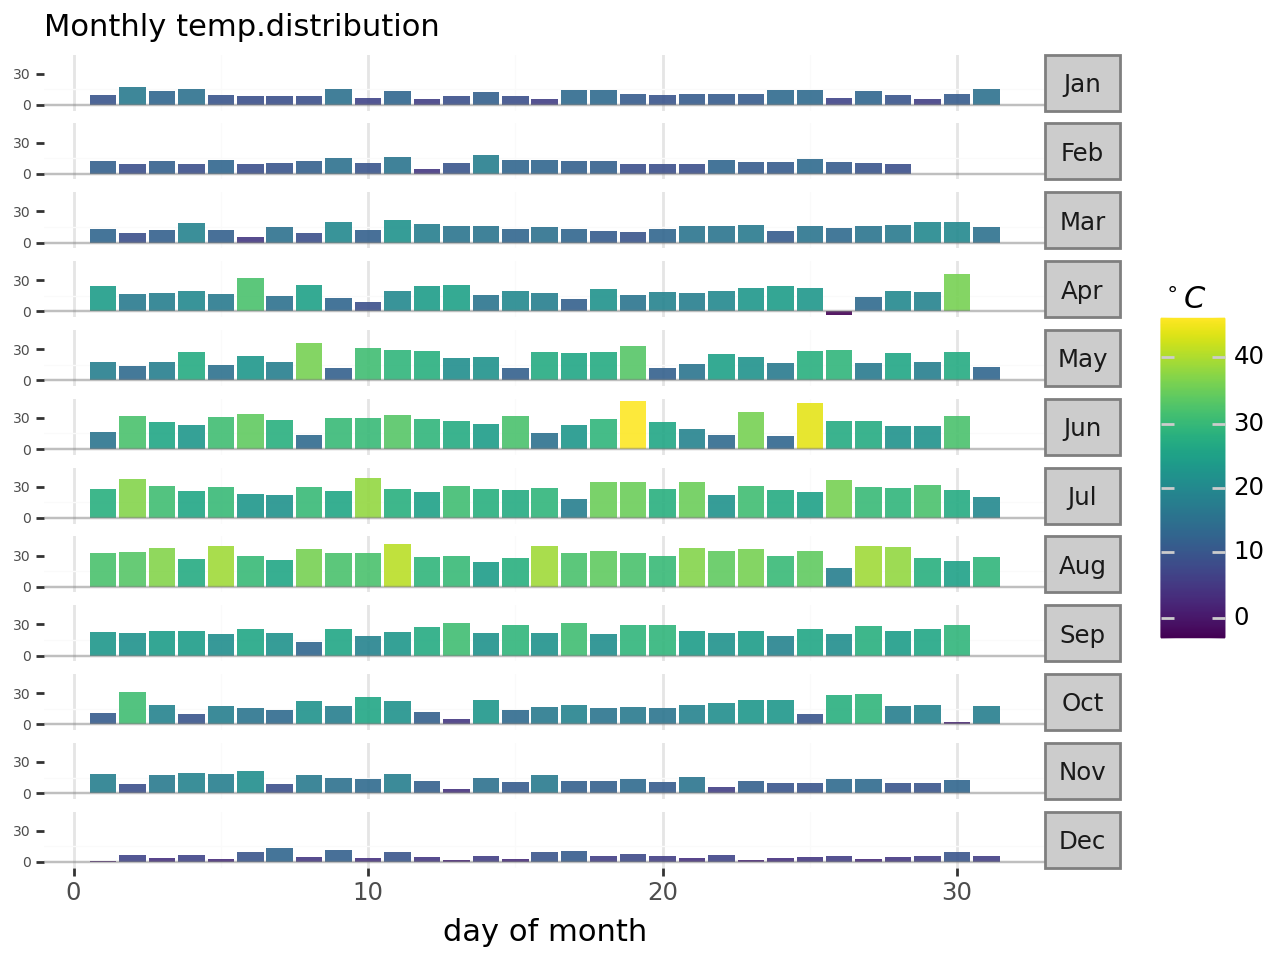

In [50]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_col(
        mapping=p9.aes(
            x="d_of_m",
            group="month",
            y="temp",
            fill="temp",
        ),
        alpha=0.9,
    )
    + p9.geom_hline(
        mapping=p9.aes(yintercept=0),
        color="gray",
        alpha=0.5,
    )
    + p9.facet_grid(rows="month")
    + p9.theme_bw()
    + p9.theme(
        panel_border=p9.element_blank(),
        strip_text_y=p9.element_text(angle=0),
        axis_text_y=p9.element_text(size=5),
        panel_grid_major_y=p9.element_blank(),
    )
    + p9.scale_y_continuous(breaks=[0, 30])
    + p9.labs(
        fill="$^\circ C$", x="day of month", y="", subtitle="Monthly temp.distribution"
    )
)
plot

---------------------

## Heatmaps

Finally, we can use __geom_bin_2d__ to create a heatmap (or maybe coldmap) of the daily temperature

The steps are:

- create an empty plot, setting our default data source
- create a binned 2d graphic
  - mapping:
    - x axis to temperature
    - y axis to month
  - setting bin width to 10C intervals
  - setting transparency
- set the black&white theme
- turn off y axis gridlines
- set the order we want the month abbreviations to appear (limits=)
- set the color map we want (shades of purple seemed best, most other colors - red, green, blue etc - have temperature connotations that might be confusing)
- set the x axis tick mark locations
- label the graphic 

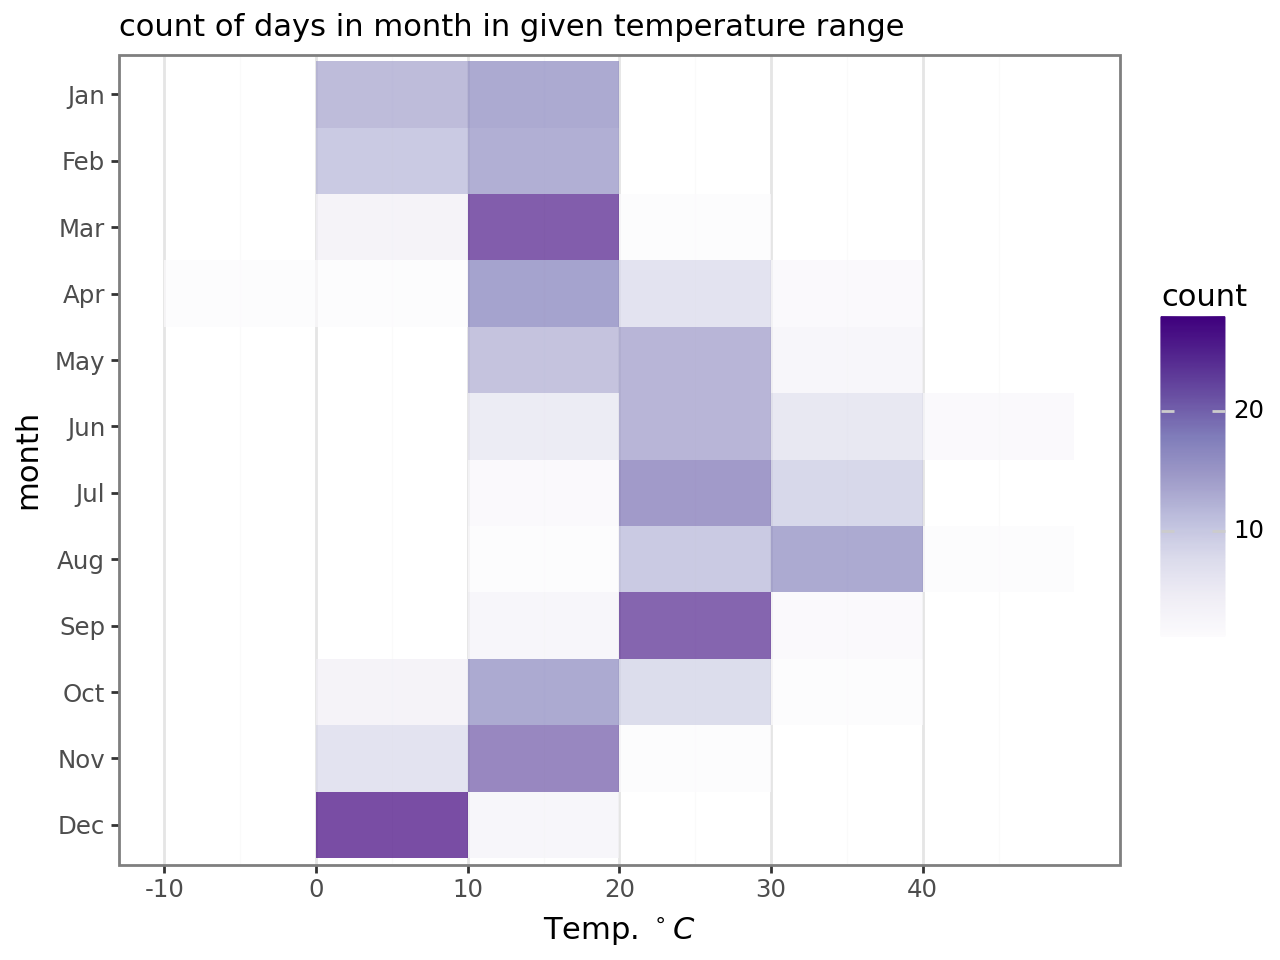

In [51]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_bin_2d(
        mapping=p9.aes(
            x="temp",
            y="month",
        ),
        binwidth=10,
        alpha=0.7,
    )
    + p9.theme_bw()
    + p9.theme(
        panel_grid_major_y=p9.element_blank(),
    )
    + p9.scale_y_discrete(limits=list(reversed(name_short)))
    + p9.scale_fill_continuous(cmap_name="Purples")
    + p9.scale_x_continuous(breaks=[-10, 0, 10, 20, 30, 40])
    + p9.labs(
        subtitle="count of days in month in given temperature range",
        x="Temp. $^\circ C$",
    )
)
plot

--------------------
## Conclusions

Once you understand the concepts behind the __plotnine__ pipeline of statistical processing -> graphic production, __plotnine__ becomes an even more powerfull system for producing visualizations.

--------------------------------

## Reproducability

In [52]:
%watermark

Last updated: 2026-03-09T16:06:56.273428+10:00

Python implementation: CPython
Python version       : 3.11.14
IPython version      : 9.10.0

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 170 Stepping 4, GenuineIntel
CPU cores   : 22
Architecture: 64bit



In [53]:
%watermark -h -iv -co

conda environment: fun_minim

Hostname: INSPIRON16

ipynbname: 2023.2.0.0
numpy    : 2.4.1
pandas   : 2.3.3
plotnine : 0.15.0
scipy    : 1.16.3



In [54]:
import contextlib

import ipynbname

with contextlib.suppress(FileNotFoundError):
    print(f"Notebook file name: {ipynbname.name()}")
# end with

Notebook file name: ridgeline
